In [2]:
import datasets
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

In [3]:
# Load MessIRve test split
messirve = datasets.load_dataset("spanish-ir/messirve", "full", revision="1.2")
test = messirve["test"]

# Count relevant documents per query
rels_per_query = Counter(test["id"])
counts = np.array(list(rels_per_query.values()))

# Summary statistics
print(f"Queries:  {len(counts):,}")
print(f"Min:      {counts.min()}")
print(f"Max:      {counts.max()}")
print(f"Mean:     {counts.mean():.2f}")
print(f"Median:   {np.median(counts):.1f}")
print(f"Std:      {counts.std():.2f}")

Queries:  170,055
Min:      1
Max:      4
Mean:     1.02
Median:   1.0
Std:      0.16


Queries:  170,055
  1 rel doc(s): 166,201 queries (97.7337%)
  2 rel doc(s):   3,698 queries (2.1746%)
  3 rel doc(s):     143 queries (0.0841%)
  4 rel doc(s):      13 queries (0.0076%)


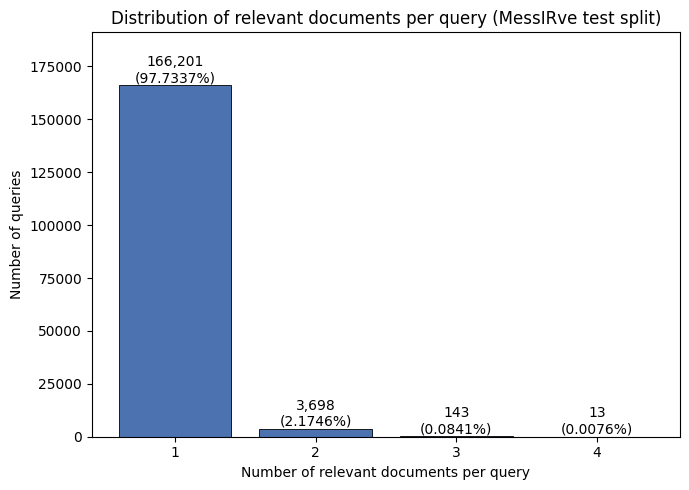

In [8]:
# Frequency of each count (1, 2, 3, 4)
freq = Counter(counts)
labels = sorted(freq.keys())
values = [freq[k] for k in labels]

# Summary statistics
print(f"Queries:  {len(counts):,}")
for k, v in sorted(freq.items()):
    print(f"  {k} rel doc(s): {v:>7,} queries ({v / len(counts) * 100:.4f}%)")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, color="#4C72B0", edgecolor="black", linewidth=0.6)

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{v:,}\n({v / len(counts) * 100:.4f}%)",
            ha="center", va="bottom", fontsize=10)

ax.set_xticks(labels)
ax.set_xlabel("Number of relevant documents per query")
ax.set_ylabel("Number of queries")
ax.set_title("Distribution of relevant documents per query (MessIRve test split)")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()